# FDSI benchmark: dataset

The FDSI benchmark is a synthetic HD-EMG dataset generated with NeuroMotion's muscle model (via
[MUniverse](https://github.com/dfarinagroup/muniverse)): a single forearm muscle (FDSI,
flexion-extension) driven by 5 wrist-kinematic conditions in each of 5 subjects, each subject
with its own simulated motor-unit pool. Every noiseless recording is re-used at 4 SNR levels,
giving 100 noisy recordings, each with the ground-truth spike trains of its simulated motor units.

This notebook reads the raw data only (`adapt-decomp-data get fdsi_benchmark-data`).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "benchmarks" / "fdsi").is_dir()
)
sys.path.insert(0, str(REPO_ROOT))  # so that benchmarks.fdsi imports from any working directory

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from benchmarks.fdsi import fdsi
from benchmarks.fdsi.spec import load_spec

spec = load_spec("benchmarks/fdsi/benchmark.yaml")
DATA_ROOT, FS = spec.data_root, spec.grid.fs
SUBJECTS, CONDITIONS, SNR_LEVELS = (
    spec.grid.subjects,
    spec.grid.conditions,
    spec.grid.snr_levels,
)
CAL_DURATION_S = spec.grid.cal_duration_s

print(
    f"{len(SUBJECTS)} subjects x {len(CONDITIONS)} conditions x {len(SNR_LEVELS)} SNR levels = "
    f"{len(spec.recordings())} noisy recordings (+ {len(SUBJECTS) * len(CONDITIONS)} noiseless ones)"
)

5 subjects x 5 conditions x 4 SNR levels = 100 noisy recordings (+ 25 noiseless ones)


## Recording metadata

Every noiseless recording carries a `metadata.json` describing the muscle model and electrode
grid it was simulated with. Some fields are fixed for the whole benchmark; the motor-unit pool
is drawn once per subject (`subject_seed`) and shared by that subject's conditions. Both are
checked below rather than assumed.

In [3]:
CONSTANT = ["n_channels", "fs", "effort_level_pct", "crosstalk_threshold", "movement_dof", "muscle"]
metadata = {
    (sub, cond): fdsi.load_recording_metadata(DATA_ROOT, sub, cond)
    for sub in SUBJECTS
    for cond in CONDITIONS
}

values = {field: {meta[field] for meta in metadata.values()} for field in CONSTANT}
assert all(len(v) == 1 for v in values.values()), f"expected constant fields, got {values}"
pd.Series({field: v.pop() for field, v in values.items()}, name="value").to_frame()

,value
n_channels,100
fs,2048
effort_level_pct,15
crosstalk_threshold,0.9
movement_dof,Flexion-Extension
muscle,FDSI


In [4]:
pools = []
for sub in SUBJECTS:
    per_cond = [metadata[(sub, cond)] for cond in CONDITIONS]
    pool = {(m["n_motor_units"], m["n_active_mus"], m["fibre_density"]) for m in per_cond}
    assert len(pool) == 1, f"{sub}: the motor-unit pool differs across conditions"
    n_mus, n_active, fibre_density = pool.pop()
    pools.append(
        {
            "subject": sub,
            "subject_seed": per_cond[0]["subject_seed"],
            "n_motor_units": n_mus,
            "n_active_mus": n_active,
            "fibre_density": fibre_density,
        }
    )
pd.DataFrame(pools).set_index("subject")

,subject_seed,n_motor_units,n_active_mus,fibre_density
subject,,,,
sub-01,0,64,39,194
sub-02,1,57,34,187
sub-03,2,87,53,190
sub-04,3,91,55,174
sub-05,4,74,45,196


## Conditions

One staircase and four triangular ramps (differing only in ramp speed), each starting with an
isometric hold whose first 5 s are the calibration window.

In [5]:
conditions = pd.DataFrame(
    [
        {
            "condition": cond,
            "type": meta["condition_type"],
            "duration_s": meta["total_duration_s"],
            "peak_angle_deg": meta["peak_angle_deg"],
            "ramp_duration_s": meta.get("ramp_duration_s"),
            "n_reps": meta.get("n_reps"),
            "step_deg": meta.get("step_deg"),
            "hold_duration_s": meta.get("hold_duration_s"),
        }
        for cond in CONDITIONS
        for meta in [metadata[(SUBJECTS[0], cond)]]
    ]
).set_index("condition")
conditions

,type,duration_s,peak_angle_deg,ramp_duration_s,n_reps,step_deg,hold_duration_s
condition,,,,,,,
staircase,staircase,125.0,40.0,10.0,NaN,10.0,5.0
triangular-ramp40s,triangular,90.0,40.0,40.0,1.0,NaN,NaN
triangular-ramp20s,triangular,90.0,40.0,20.0,2.0,NaN,NaN
triangular-ramp10s,triangular,90.0,40.0,10.0,4.0,NaN,NaN
triangular-ramp5s,triangular,90.0,40.0,5.0,8.0,NaN,NaN


## Wrist angle and contraction level

Each condition drives a different wrist-angle trajectory, while the target contraction level
stays fixed for the whole recording. The angle trace is the same for every subject; only the
motor-unit pool differs.

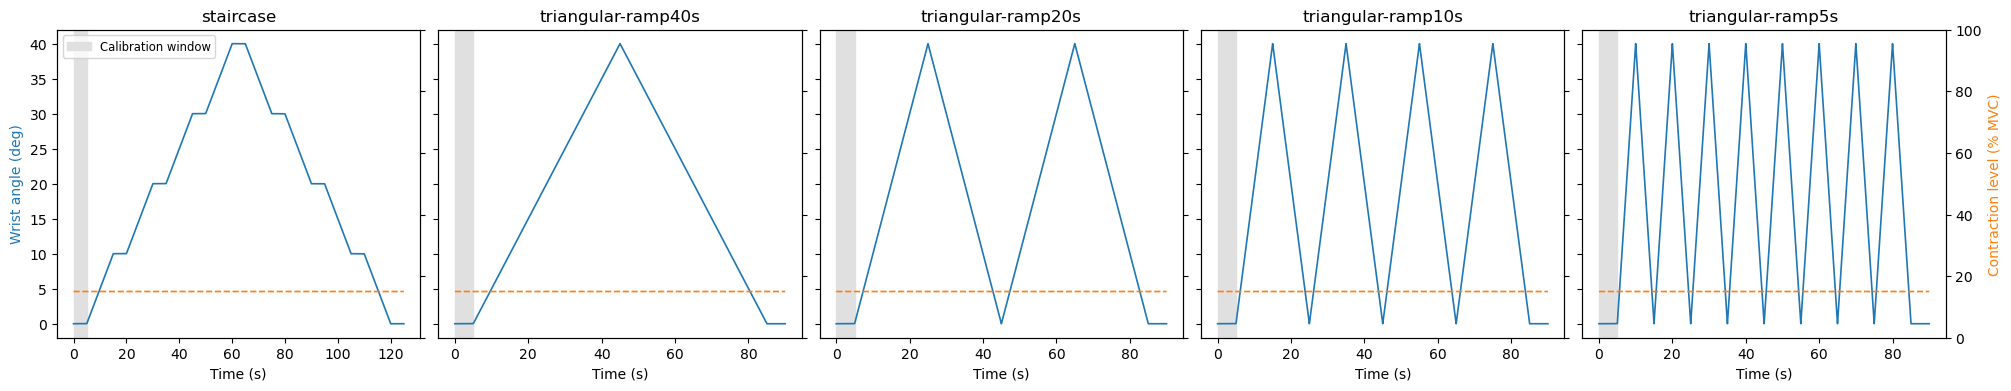

In [6]:
sub = SUBJECTS[0]
reference = fdsi.load_angle_profile(DATA_ROOT, sub, CONDITIONS[0])
assert all(
    np.array_equal(fdsi.load_angle_profile(DATA_ROOT, s, CONDITIONS[0]), reference)
    for s in SUBJECTS[1:]
)

fig, axs = plt.subplots(1, len(CONDITIONS), figsize=(20, 3.8), sharey=True, layout="constrained")
for i, (ax, cond) in enumerate(zip(axs, CONDITIONS)):
    angle = fdsi.load_angle_profile(DATA_ROOT, sub, cond)
    effort = fdsi.load_effort_profile(DATA_ROOT, sub, cond)
    t = np.arange(len(angle)) / FS

    ax.axvspan(0, CAL_DURATION_S, color="0.88", zorder=0, label="Calibration window")
    ax.plot(t, angle, color="C0", lw=1.2)
    ax.set(title=cond, xlabel="Time (s)")
    effort_ax = ax.twinx()
    effort_ax.plot(t, effort * 100, color="C1", ls="--", lw=1.2)
    effort_ax.set_ylim(0, 100)
    effort_ax.tick_params(axis="y", labelright=i == len(CONDITIONS) - 1)
    if i == len(CONDITIONS) - 1:
        effort_ax.set_ylabel("Contraction level (% MVC)", color="C1")
axs[0].set_ylabel("Wrist angle (deg)", color="C0")
axs[0].legend(loc="upper left", fontsize="small")
plt.show()

## Noise levels

Each noiseless recording is re-used at 4 target SNR levels, with the noise power of each channel
set to hit the target: checked below against every recording's `noise_metadata.json`.

In [7]:
deviation = max(
    abs(meta["snr_db_actual"] - meta["snr_db_target"])
    for rec in spec.recordings()
    for meta in [fdsi.load_noise_metadata(DATA_ROOT, rec)]
)
print(
    f"{len(spec.recordings())} noisy recordings: largest |realised - target SNR| = {deviation:.4f} dB"
)

100 noisy recordings: largest |realised - target SNR| = 0.0100 dB


One second of a central channel, noiseless against each noise level, with the SNR measured on
that channel and window next to its target.

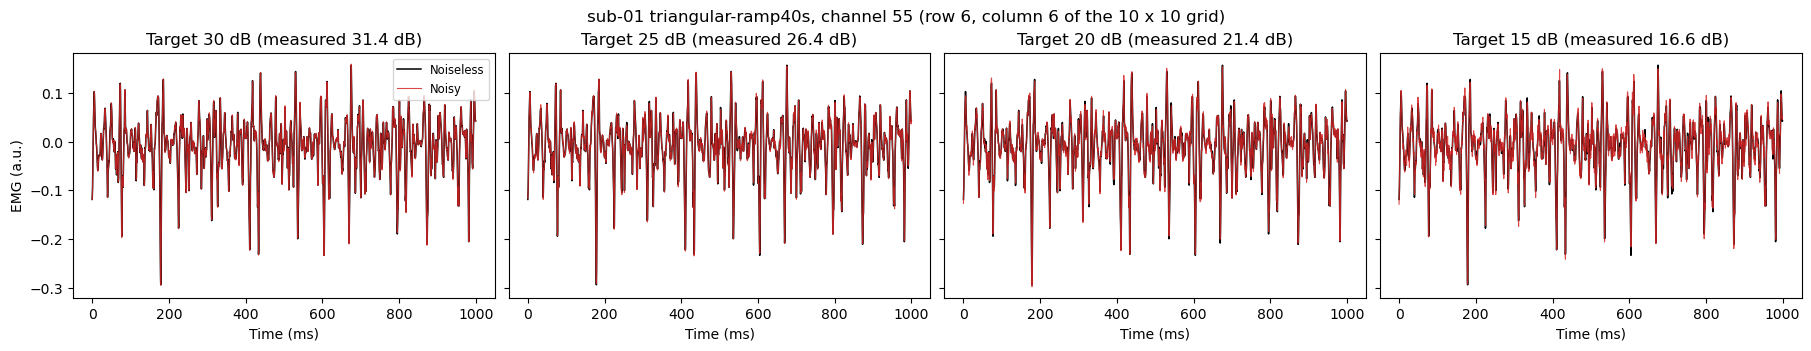

In [8]:
sub, cond = SUBJECTS[0], "triangular-ramp40s"
meta = metadata[(sub, cond)]
row, col = meta["n_rows"] // 2, meta["center_column"] - meta["selected_columns"][0]
channel = row * meta["n_cols"] + col

start = int(30.0 * FS)
window = slice(start, start + FS)
t_ms = np.arange(FS) / FS * 1000
clean = fdsi.load_clean_emg(DATA_ROOT, sub, cond)[window, channel]

fig, axs = plt.subplots(
    1, len(SNR_LEVELS), figsize=(18, 3.4), sharex=True, sharey=True, layout="constrained"
)
for ax, snr in zip(axs, SNR_LEVELS):
    noisy = fdsi.load_raw_emg(DATA_ROOT, fdsi.Recording(sub, cond, snr))[window, channel]
    measured = 20 * np.log10(np.sqrt(np.mean(clean**2)) / np.sqrt(np.mean((noisy - clean) ** 2)))
    ax.plot(t_ms, clean, color="black", lw=1.1, label="Noiseless")
    ax.plot(t_ms, noisy, color="C3", lw=0.8, alpha=0.85, label="Noisy")
    ax.set(title=f"Target {snr} dB (measured {measured:.1f} dB)", xlabel="Time (ms)")
axs[0].set_ylabel("EMG (a.u.)")
axs[0].legend(loc="upper right", fontsize="small")
fig.suptitle(
    f"{sub} {cond}, channel {channel} (row {row + 1}, column {col + 1} of the {meta['n_rows']} x {meta['n_cols']} grid)"
)
plt.show()

## Ground truth

Each condition's spike trains of its simulated motor units: the reference every RoA in the
benchmark is computed against. Calibration keeps the decomposed units that match one of
them (`gt_unit` in the benchmark tables is its column here).

In [9]:
rows = []
for cond in CONDITIONS:
    spikes = np.load(fdsi.gt_spikes_path(DATA_ROOT, sub, cond), allow_pickle=True)["spikes"]
    counts = np.array([len(s) for s in spikes])
    rates = counts / conditions.loc[cond, "duration_s"]
    rows.append(
        {
            "condition": cond,
            "simulated units": len(spikes),
            "active units": int((counts > 0).sum()),
            "median rate (Hz)": float(np.median(rates[counts > 0])),
        }
    )
display(pd.DataFrame(rows).set_index("condition"))

,simulated units,active units,median rate (Hz)
condition,,,
staircase,64,39,15.488000
triangular-ramp40s,64,39,15.422222
triangular-ramp20s,64,39,15.488889
triangular-ramp10s,64,39,15.444444
triangular-ramp5s,64,39,15.533333
